In [1]:
from scipy.interpolate import make_interp_spline, splprep, splev
import numpy as np
import torch
from collections import defaultdict

In [11]:
def plot_streamlines(mesh):
    import matplotlib.pyplot as plt
    import numpy as np

    streamlines = mesh.streamlines
    nodes = mesh.x[:, 0:2]  # Assuming we are using 2D coordinates (x, y)
    edges = mesh.edge_index
    # Create a figure for plotting
    plt.figure(figsize=(8, 8))
    
    # Plot the mesh by drawing the triangles
    for face in mesh.faces.T:  # Transposing to iterate through each face
        triangle = nodes[face, :]
        plt.fill(triangle[:, 0], triangle[:, 1], edgecolor='gray', fill=False, linewidth=0.5)
    
    for streamline in streamlines:
        streamline = np.array(streamline)  # Convert to numpy array for easier plotting
        plt.plot(streamline[:, 0], streamline[:, 1],'r')
    try:
            for i in range(len(mesh.streamline_intersections)):
                intersection = mesh.streamline_intersections[i]
                plt.plot(intersection[0],intersection[1],'ok')
    except:
        print('no streamline intersections')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Streamlines over Mesh')
    plt.gca().set_aspect('equal', adjustable='box')
#     plt.legend()
    plt.grid(True)
    
    plt.show()

In [3]:
mesh = torch.load('good_mesh.pt')

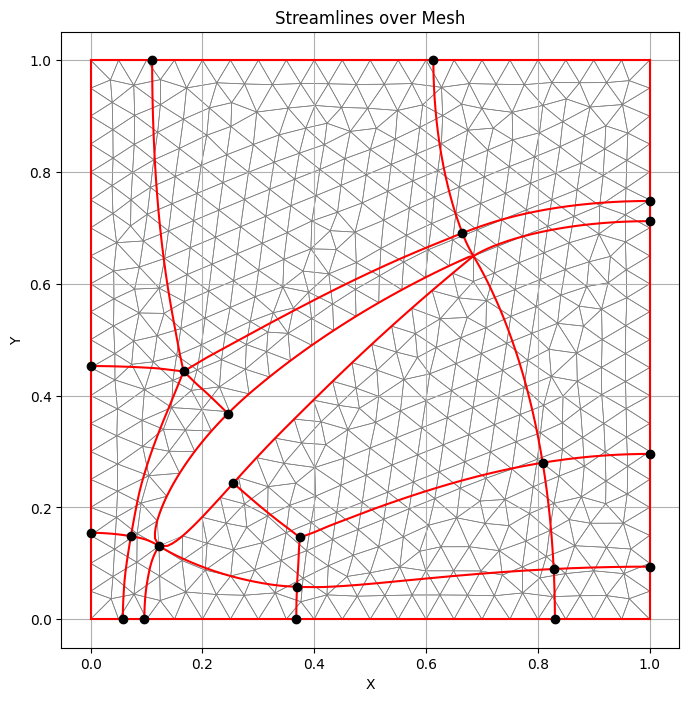

In [12]:
plot_streamlines(mesh)

In [5]:
class StreamlineSimplificator:
    def __init__(self,mesh):
        self.mesh = mesh
        self.streamline_splines = self.get_streamlines_as_splines()
        self.intersection_data = self.find_all_intersections()

        
        
    def find_all_intersections(self, tolerance=1e-6):
        
        splines = self.streamline_splines 
        all_intersections = [] 

        for i in range(len(splines)):
            for j in range(i+1, len(splines)):
                if splines[i] is None or splines[j] is None:
                    continue

                intersections = self.find_spline_intersections_with_params(splines[i], splines[j], tolerance)

                for point, t1, t2 in intersections:
                    all_intersections.append((point, i, t1, j, t2))

        unique_points = []
        point_indices = {}  

        spline_intersections = defaultdict(list)  # Maps spline_idx to [(point_idx, t), ...]
        connectivity = defaultdict(list)  # Maps point_idx to [spline_idx, ...]

        for point, spline1_idx, t1, spline2_idx, t2 in all_intersections:
            # Check if this point is already in unique_points
            is_new_point = True
            point_idx = None

            for idx, existing_point in enumerate(unique_points):
                if np.linalg.norm(np.array(point) - np.array(existing_point)) < tolerance:
                    is_new_point = False
                    point_idx = idx
                    break

            if is_new_point:
                point_idx = len(unique_points)
                unique_points.append(point)

            # Update spline_intersections
            spline_intersections[spline1_idx].append((point_idx, t1))
            spline_intersections[spline2_idx].append((point_idx, t2))

            # Update connectivity
            if spline1_idx not in connectivity[point_idx]:
                connectivity[point_idx].append(spline1_idx)
            if spline2_idx not in connectivity[point_idx]:
                connectivity[point_idx].append(spline2_idx)

        # Sort spline_intersections by parameter value t
        for spline_idx in spline_intersections:
            spline_intersections[spline_idx].sort(key=lambda x: x[1])

        return {
            'points': unique_points,
            'spline_intersections': dict(spline_intersections),
            'connectivity': dict(connectivity)
        }, intersections

    def get_intersections(self):

        intersections = [] 
        dicc_id = 0  
        for i in range(len(self.streamline_splines)):
            streamline_I = self.streamline_splines[i]  
            for j in range(i + 1, len(self.streamline_splines)): 

                streamline_J = self.streamline_splines[j]

                confirmed_intersection = self.find_spline_intersections_with_params(streamline_I, streamline_J)
    
                if confirmed_intersection:

                    intersections.append(confirmed_intersection)
                
        return intersections

    def get_streamlines_as_splines(self):
        splines = []
        streamlines = self.mesh.streamlines
        for i in range(len(streamlines)):
            streamline = np.array(streamlines[i])  
            x = streamline[:, 0]
            y = streamline[:, 1]

            
            if x.size == 2:

                tck, u = splprep([x, y], s=0, k=1)  # Use k=1 for linear interpolation
                splines.append([tck, u])
            else:
                # For streamlines with more points, use standard B-spline fitting
                tck, u = splprep([x, y], s=0)
                splines.append([tck, u])

        return splines

    def find_spline_intersections_with_params(self,spline1, spline2, tolerance=1e-6, num_samples=10):

        tck1, u1 = spline1
        tck2, u2 = spline2

        u1_fine = np.linspace(0, 1, num_samples)
        u2_fine = np.linspace(0, 1, num_samples)

        points1 = np.array(splev(u1_fine, tck1)).T
        points2 = np.array(splev(u2_fine, tck2)).T

        # Find potential intersection regions
        potential_intersections = []

        # For each segment in spline1, check for potential intersections with segments in spline2
        for i in range(len(points1) - 1):
            for j in range(len(points2) - 1):
                # Check if the bounding boxes of the segments overlap
                min_x1, max_x1 = min(points1[i][0], points1[i+1][0]), max(points1[i][0], points1[i+1][0])
                min_y1, max_y1 = min(points1[i][1], points1[i+1][1]), max(points1[i][1], points1[i+1][1])

                min_x2, max_x2 = min(points2[j][0], points2[j+1][0]), max(points2[j][0], points2[j+1][0])
                min_y2, max_y2 = min(points2[j][1], points2[j+1][1]), max(points2[j][1], points2[j+1][1])

                # If bounding boxes overlap, add to potential intersections
                if (min_x1 <= max_x2 and max_x1 >= min_x2 and
                    min_y1 <= max_y2 and max_y1 >= min_y2):
                    u1_val = u1_fine[i]
                    u2_val = u2_fine[j]
                    potential_intersections.append((u1_val, u2_val))

        # Refine potential intersections
        confirmed_intersections = []

        for u1_val, u2_val in potential_intersections:
            # Define a function to find the root of (distance between points on the splines)
            def distance_func(params):
                t1, t2 = params
                # Ensure t1 and t2 are within [0, 1]
                t1 = max(0, min(1, t1))
                t2 = max(0, min(1, t2))

                point1 = np.array(splev(t1, tck1)).reshape(2)
                point2 = np.array(splev(t2, tck2)).reshape(2)

                return [point1[0] - point2[0], point1[1] - point2[1]]

            # Initial guess
            initial_guess = [u1_val, u2_val]

            # Solve for intersection
            try:
                from scipy.optimize import fsolve
                t1_intersect, t2_intersect = fsolve(distance_func, initial_guess,maxfev=1000)

                # Check if t1_intersect and t2_intersect are within [0, 1]
                if 0 <= t1_intersect <= 1 and 0 <= t2_intersect <= 1:
                    point1 = np.array(splev(t1_intersect, tck1)).reshape(2)
                    point2 = np.array(splev(t2_intersect, tck2)).reshape(2)

                    # Check if points are close enough
                    if np.linalg.norm(point1 - point2) < tolerance:
                        # Average the two points to get the intersection point
                        intersection_point = ((point1[0] + point2[0])/2, (point1[1] + point2[1])/2)

                        # Check if this intersection is already in the list
                        is_duplicate = False
                        for existing_point, _, _ in confirmed_intersections:
                            if np.linalg.norm(np.array(existing_point) - np.array(intersection_point)) < tolerance:
                                is_duplicate = True
                                break

                        if not is_duplicate:
                            confirmed_intersections.append((intersection_point, t1_intersect, t2_intersect))
            except:
                # If fsolve fails, skip this potential intersection
                continue

        return confirmed_intersections

In [6]:
simp = StreamlineSimplificator(mesh)

/tmp/ipykernel_16707/2048638811.py:156: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  t1_intersect, t2_intersect = fsolve(distance_func, initial_guess,maxfev=1000)


In [9]:
mesh.streamline_intersections = simp.intersection_data[0]['points']


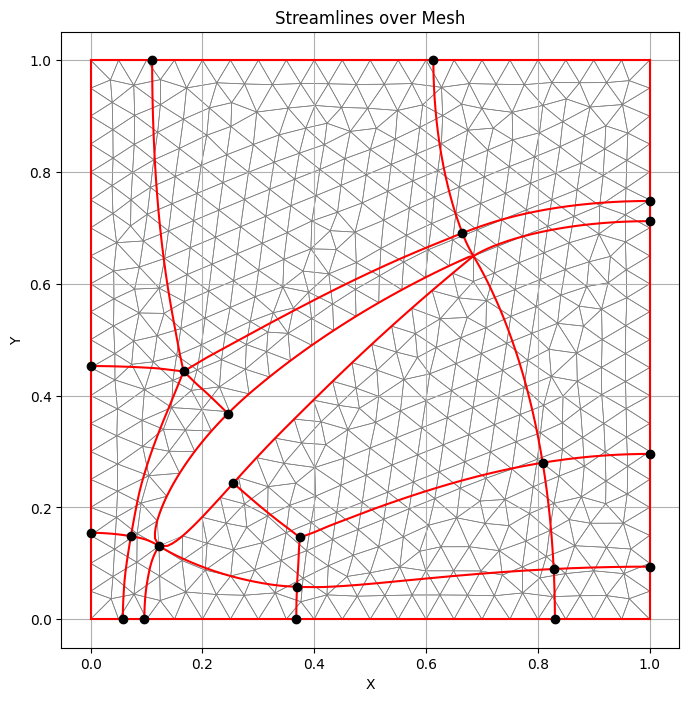

In [10]:
# mesh.streamline_intersections = simp.spline_intersections
plot_streamlines(mesh)

In [23]:
def split_splines_at_intersections(splines, intersection_data):
    """
    Split splines at intersection points.
    
    Parameters:
    -----------
    splines : list
        List of splines, where each spline is represented as [tck, u].
    intersection_data : dict
        Dictionary containing intersection information from find_all_intersections.
        
    Returns:
    --------
    tuple
        (split_splines, spline_segments_map)
        - split_splines: List of all split splines
        - spline_segments_map: Dictionary mapping original spline index to list of
          indices of its segments in split_splines
    """
    split_splines = []
    spline_segments_map = {}
    
    for spline_idx, spline in enumerate(splines):
        if spline is None:
            spline_segments_map[spline_idx] = []
            continue
            
        # Get intersection points for this spline
        if spline_idx not in intersection_data['spline_intersections']:
            # No intersections, keep original spline
            split_splines.append(spline)
            spline_segments_map[spline_idx] = [len(split_splines) - 1]
            continue
        
        intersections = intersection_data['spline_intersections'][spline_idx]
        
        # Sort intersections by parameter value
        intersections.sort(key=lambda x: x[1])
        
        # Split the spline
        tck, u = spline
        segments = []
        
        # Add starting point (t=0)
        split_points = [0.0]
        
        # Add intersection points
        for _, t in intersections:
            split_points.append(t)
        
        # Add ending point (t=1)
        split_points.append(1.0)
        
        # Remove duplicates and ensure they're sorted
        split_points = sorted(list(set(split_points)))
        
        # Create segments
        segment_indices = []
        for i in range(len(split_points) - 1):
            t_start = split_points[i]
            t_end = split_points[i + 1]
            
            # Skip very small segments
            if t_end - t_start < 1e-6:
                continue
                
            # Extract segment
            segment = extract_spline_segment(tck, t_start, t_end)
            split_splines.append(segment)
            segment_indices.append(len(split_splines) - 1)
        
        spline_segments_map[spline_idx] = segment_indices
    
    return split_splines, spline_segments_map